# 第077课 精确概率推断

给定参数，计算未知状态的边缘与后验。穷举、变量消元与两遍消息传递独立实现后相互比较。

In [1]:
import json
from pathlib import Path
from exact_inference import *
from experiment import run
from IPython.display import display, Image
params=json.loads(Path('data/chain.json').read_text())
factors=chain_factors(**params)
print(params)
print('各因子范围:',[f.scope for f in factors])

{'prior': [0.6, 0.4], 'transition': [[0.85, 0.15], [0.25, 0.75]], 'length': 4, 'emission': [0.1, 0.9]}
各因子范围: [('X0',), ('X0', 'X1'), ('X1', 'X2'), ('X2', 'X3'), ('X3', 'E')]


## 1 将末端观测固定，再消去隐藏状态

In [2]:
ve,z,trace=eliminate(factors,'X0',{'E':1},['X3','X2','X1'])
print('X0的后验:',ve.table)
print('证据概率:',z)
for row in trace:
    print(row)  # 清楚显示每次临时范围和条目数。
brute,bz=enumerate_query(factors,'X0',{'E':1})
print('穷举对照:',brute.table,'差:',abs(brute.table[(1,)]-ve.table[(1,)]))

X0的后验: {(0,): 0.4974277799762565, (1,): 0.5025722200237436}
证据概率: 0.40432
{'variable': 'X3', 'joint_scope': ['X2', 'X3'], 'entries': 4, 'result_scope': ['X2']}
{'variable': 'X2', 'joint_scope': ['X1', 'X2'], 'entries': 4, 'result_scope': ['X1']}
{'variable': 'X1', 'joint_scope': ['X0', 'X1'], 'entries': 4, 'result_scope': ['X0']}
穷举对照: {(0,): 0.4974277799762564, (1,): 0.5025722200237436} 差: 0.0


X0 前向 [0.6, 0.4] 后向 [0.33520000000000005, 0.508] 归一化结果 [0.4974277799762565, 0.5025722200237436]
X1 前向 [0.61, 0.39] 后向 [0.29200000000000004, 0.5800000000000001] 归一化结果 [0.44054214483577364, 0.5594578551642264]
X2 前向 [0.616, 0.384] 后向 [0.22000000000000003, 0.7000000000000001] 归一化结果 [0.33518005540166207, 0.6648199445983379]
X3 前向 [0.6195999999999999, 0.3804] 后向 [0.1, 0.9] 归一化结果 [0.15324495449149186, 0.8467550455085081]
证据概率: 0.40432


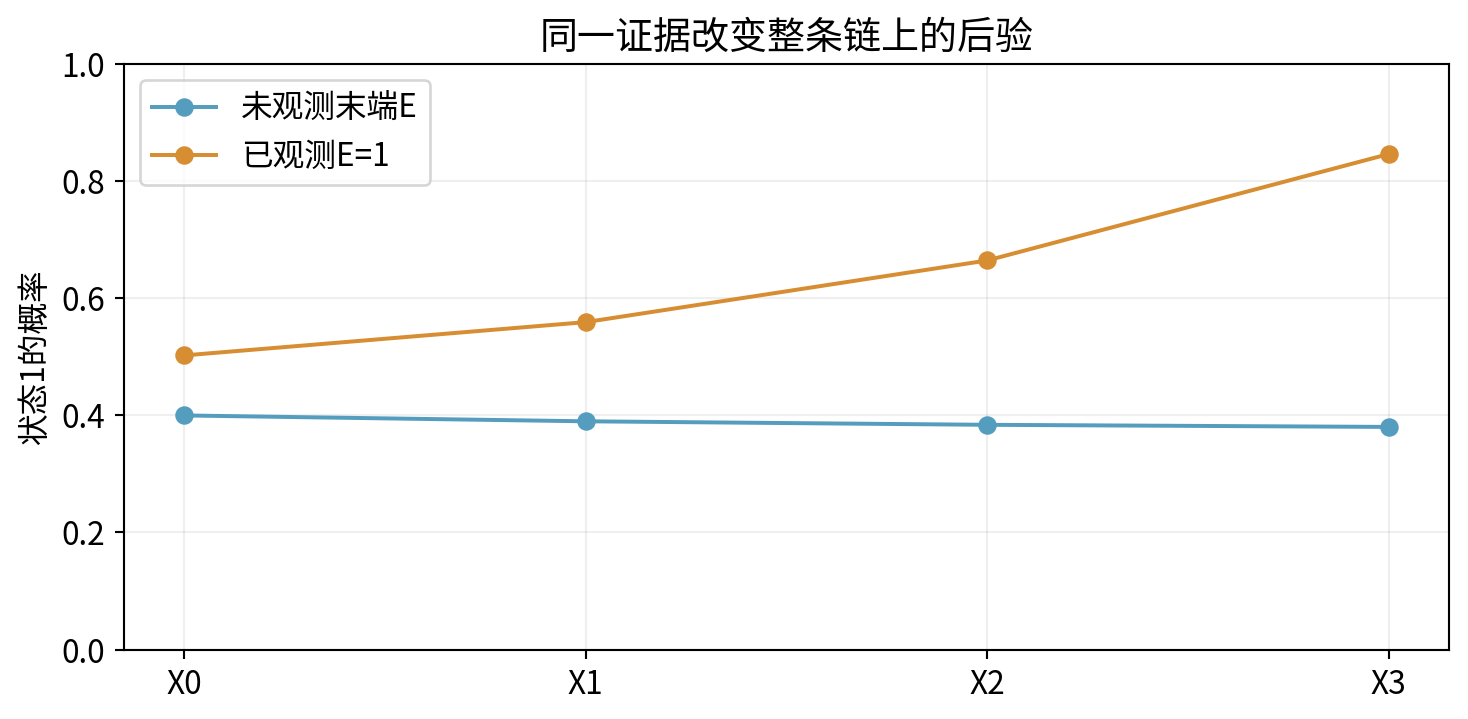

In [3]:
marginals,mass,forward,backward=chain_sum_product(**params)
for i,(a,b,m) in enumerate(zip(forward,backward,marginals)):
    print('X'+str(i),'前向',a,'后向',b,'归一化结果',m)
print('证据概率:',mass)
display(Image(filename='figures/04_posteriors.png'))

## 2 相同精确答案可能需要不同大小的中间表

顺序: ['L0', 'L1', 'L2', 'L3', 'L4', 'C']
P(L5=1): 0.45000000000000007 Z: 4096.0 峰值条目: 4
顺序: ['C', 'L0', 'L1', 'L2', 'L3', 'L4']
P(L5=1): 0.45 Z: 4096.0 峰值条目: 128


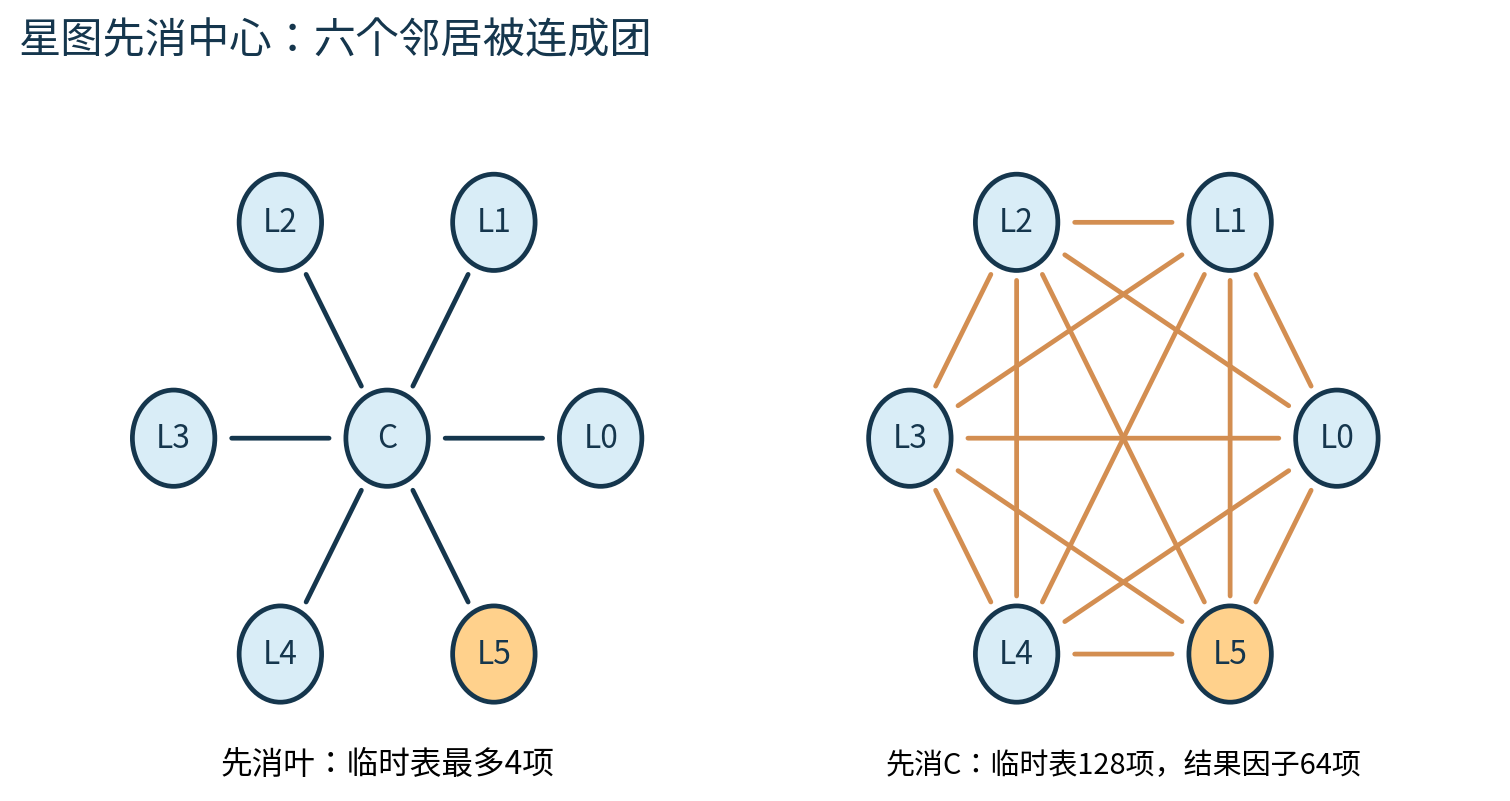

In [4]:
star=star_factors()
for order in (['L0','L1','L2','L3','L4','C'],['C','L0','L1','L2','L3','L4']):
    value,mass,trace=eliminate(star,'L5',order=order)
    print('顺序:',order)
    print('P(L5=1):',value.table[(1,)],'Z:',mass,'峰值条目:',max(t['entries'] for t in trace))
display(Image(filename='figures/05_order.png'))

In [5]:
impossible=chain_factors([.6,.4],[[.85,.15],[.25,.75]],2,[0.,0.])
try:
    eliminate(impossible,'X0',{'E':1})
except ValueError as error:
    print('正确拒绝零概率证据:',str(error))
else:
    raise RuntimeError('impossible evidence was not rejected')
print('完整实验:',run()['max_method_error'])

正确拒绝零概率证据: zero or invalid evidence mass
完整实验: 1.1102230246251565e-16


In [6]:
import unittest
from test_experiment import Checks
tests=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromTestCase(Checks))
if not tests.wasSuccessful():
    raise RuntimeError('unit tests failed')
print('本Notebook所有计算和测试完成。')

.

.

.

.

.

.

----------------------------------------------------------------------
Ran 6 tests in 0.007s

OK


本Notebook所有计算和测试完成。


## 复盘

消元改变计算顺序，不改变目标分布。树上两遍sum-product为精确推断；一般有环图直接迭代消息不享有同样保证。